# Demand Forecasting with Prophet

This notebook explores historical retail sales data and builds a forecasting model using Facebook Prophet to predict future demand.

## Objectives

- Explore historical demand patterns
- Identify trends and seasonality
- Prepare data for time series forecasting
- Train a Prophet forecasting model
- Generate demand predictions for future periods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

sns.set_style("whitegrid")

Importing plotly failed. Interactive plots will not work.


In [3]:
# Load dataset
df = pd.read_csv("../data/raw/train.csv")

# Inspect data
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (913000, 4)

Columns:
Index(['date', 'store', 'item', 'sales'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [5]:
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [7]:
daily_sales = df.groupby("date")["sales"].sum().reset_index()

daily_sales.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


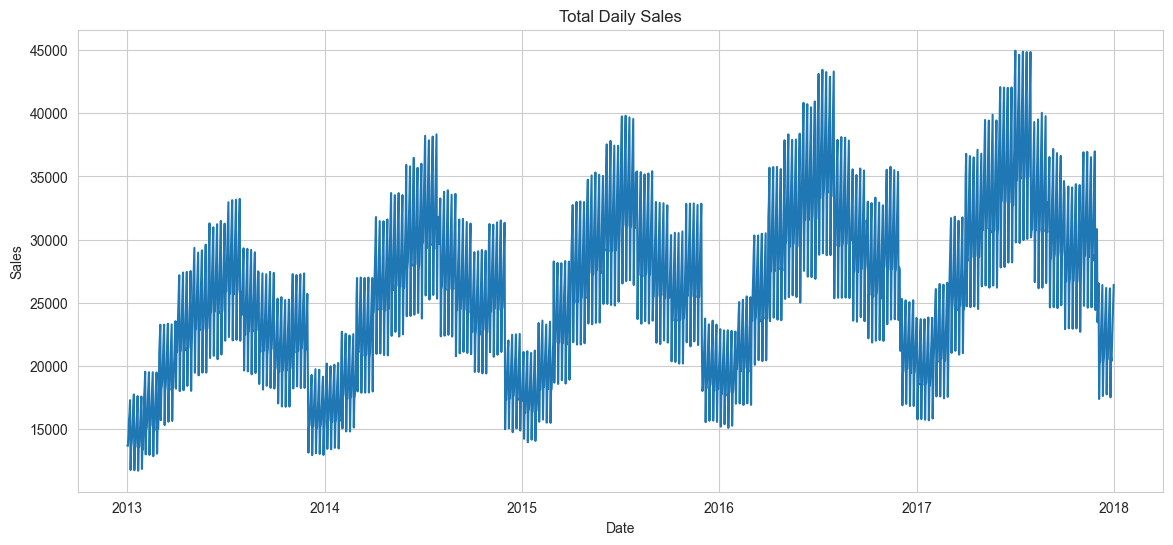

In [8]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [9]:
prophet_df = daily_sales.rename(columns={
    "date": "ds",
    "sales": "y"
})

prophet_df.head()

,ds,y
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


In [10]:
model = Prophet()
model.fit(prophet_df)

12:42:27 - cmdstanpy - INFO - Chain [1] start processing
12:42:30 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future = model.make_future_dataframe(periods=90)

future.tail()

,ds
1911,2018-03-27
1912,2018-03-28
1913,2018-03-29
1914,2018-03-30
1915,2018-03-31


In [12]:
forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1911,2018-03-27,27581.140946,26100.590003,29067.947088
1912,2018-03-28,27778.810728,26239.791827,29205.855103
1913,2018-03-29,29588.968692,28174.817991,31069.331162
1914,2018-03-30,31445.005170,29901.849113,32966.897892
1915,2018-03-31,33342.715895,31840.822952,34776.532935


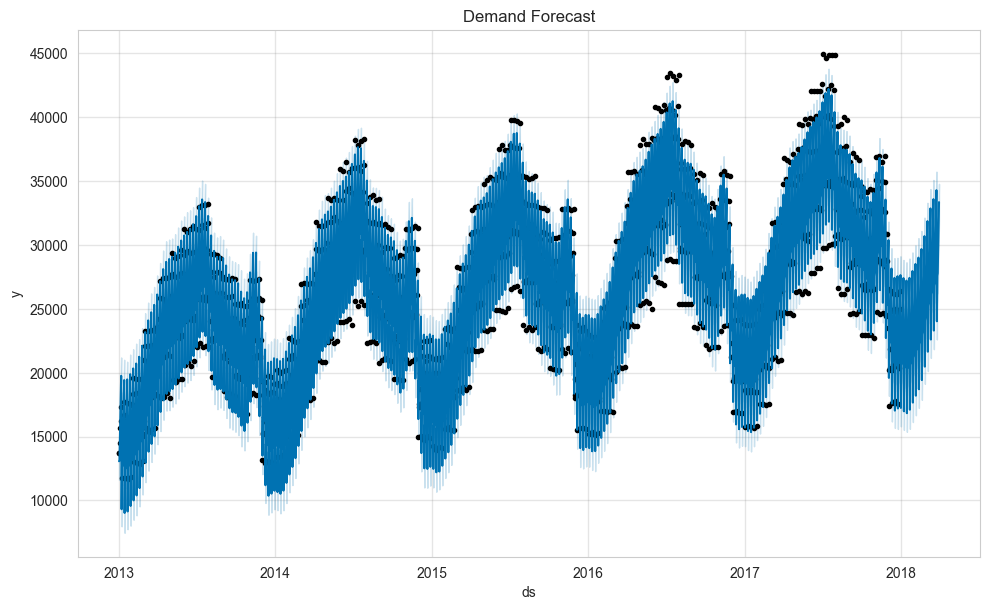

In [13]:
fig1 = model.plot(forecast)
plt.title("Demand Forecast")
plt.show()

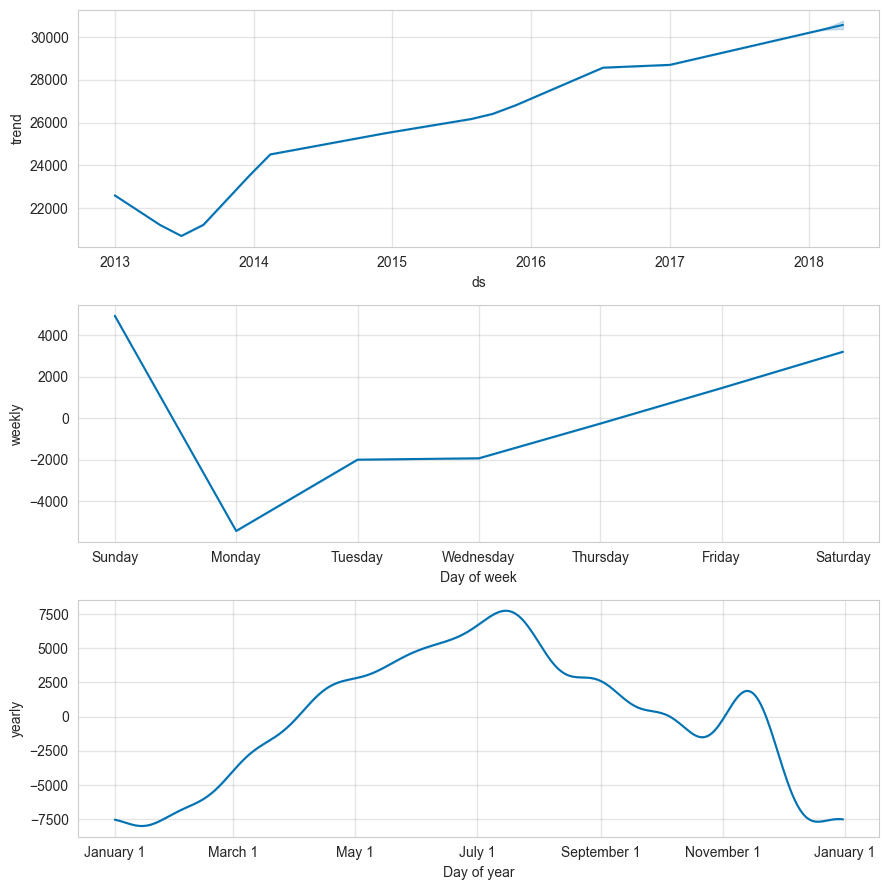

In [14]:
fig2 = model.plot_components(forecast)
plt.show()

## Business Insights

The forecasting model shows overall demand trends and seasonal patterns in retail sales.

Key insights:
- Demand shows stable growth over time
- Seasonal patterns appear across the year
- The forecast provides a projection for the next 90 days

Potential business applications:
- Inventory planning
- Supply chain optimization
- Demand-driven decision making